### Dynamic College and Labor Supply Model (with Wage Shocks)

This model describes an individual’s lifetime decision between **education** and **working**, accounting for **consumption**, **savings**, **human capital accumulation**, and **wage risk**. The wage now depends on a persistent AR(1) shock.

At the initial period \( t = 0 \), the agent chooses whether to attend college or enter the labor market, comparing the expected values of each path. If college is chosen, the agent consumes while incurring education costs and increasing human capital. Upon graduation, the agent enters the labor market, deciding how much to **consume** and **work**, with wages depending on accumulated human capital and both types of shocks.

- If **college** is chosen, the agent remains a student for $ t_{\text{college}} = 4 $ years, during which they **consume**, **pay tuition**, and **accumulate human capital**. The psychic cost $ \kappa_X $ is also incurred each year.
- After graduation, the agent enters the **labor market** with enhanced human capital and starts making labor supply decisions.

- If **work** is chosen directly, the agent starts earning immediately and decides each period how much to **consume** and **work**, while human capital grows on-the-job.

### Variables
- $w^{\text{base}}_t$: Deterministic wage profile for period $t$ (from $w\_vec[t]$ in code)
- $k_t$: Human capital
- $\alpha$: Human capital return parameter
- $\tau$: Tax rate
- $z_t$: Persistent (AR(1)) shock in levels



#### Initial Decision ($t = 0$)

$$
V_0 = \max \left\{ \mathbb{E}_{z_0} \left[ V^E_0 \right], \mathbb{E}_{z_0} \left[ V^W_0 \right] \right\}
$$



#### College ($s_t = E$)

$$
V^E_t(E, A_t, k_t, z_t) = \max_{c_t} \left\{ \frac{c_t^{1-\rho}}{1-\rho} - \kappa_X + \beta\, \mathbb{E}_{z_{t+1}} \left[ V^W_{t+1}(W, A_{t+1}, k_{t+1}, z_{t+1}) \right] \right\}
$$

$$
A_{t+1} = (1 + r) A_t - c_t - \text{college cost}
$$

$$
\kappa_X = \kappa \frac{1}{(HC_t+1)^2}
$$

$$
k_{t+1} =
\begin{cases}
k_t + h_t^E & \text{for } t \leq t_{\text{college}} \\
k_t + h_t   & \text{for } t > t_{\text{college}}
\end{cases}
$$



#### Labor Market ($s_t = W$)

$$
V^W_t(W, A_t, k_t, z_t, \epsilon_t) = \max_{c_t, h_t} \left\{ \frac{c_t^{1-\rho}}{1-\rho} -\varphi \frac{h_t^{1+\eta}}{1+\eta} + \beta\, \mathbb{E}_{z_{t+1}} \left[ V^W_{t+1}(W, A_{t+1}, k_{t+1}, z_{t+1}) \right] \right\}
$$

$$
A_{t+1} = (1 + r)A_t + (1 - \tau_{\text{tax}})\, w_t\, h_t - c_t
$$



$$
k_{t+1} = k_t + h_t
$$

#### Wage Process (with Shocks)
$$
w_t = w^{\text{base}}_t \cdot (1 + \alpha k_t) \cdot z_t
$$
- $z_t$: Persistent AR(1) shock: $z_{t+1} = \rho z_t + \eta_{t+1}$, $\eta_{t+1} \sim N(0, \sigma^2_z)$  




---

**Notes:**  

- Wage risk enters through persistent (AR(1)).

---

### Model Parameter Settings


| **Parameter**          | **Value**                    | **Description**                                                      |
|------------------------|-----------------------------|----------------------------------------------------------------------|
| `T`                    | 50                          | Number of periods (lifetime horizon)                                 |
| `t_college`            | 4                           | College duration (years)                                             |
| `beta` (`β`)           | 0.97                        | Discount factor (annual)                                             |
| `rho` (`ρ`)            | 1.0                         | Relative risk aversion (CRRA)                                        |
| `r`                    | 0.03                        | Real interest rate (annual)                                          |
| `a_min`                | 0.0                         | Minimum asset level                                                  |
| `a_max`                | 20.0                        | Maximum asset level (grid)                                           |
| `Na`                   | 30                          | Number of grid points for assets                                     |
| `k_max`                | 30.0                        | Maximum human capital (grid)                                         |
| `Nk`                   | 30                          | Number of grid points for human capital                              |
| `w` (`w_0`)            | 12.5                        | Base wage (deterministic component)                                  |
| `tau` (`τ`)            | 0.25                        | Labor income tax rate                                                |
| `eta` (`η`)            | 2.0                         | Inverse Frisch elasticity (elasticity ≈ 0.5)                         |
| `alpha` (`α`)          | 0.08                        | Wage increase per unit human capital                                 |
| `phi` (`ϕ`)            | 20.0                        | Weight on disutility of labor                                        |
| `college_cost`         | 1.2                         | Annual direct college cost                                           |
| `college_boost`        | 2.0                         | Human capital gain per year in college                               |
| `kappa` (`κ`)          | 0.5                         | Scale parameter for psychic cost: $\kappa_X = \kappa \log(k_t)$      |
| `y`                    | 0.6                         | Non-labor income (if used)                                           |
| `simN`                 | 5000                        | Number of simulated individuals                                      |
| `sim_a_init`           | `rand(rng, simN) .* 10`     | Initial asset distribution: uniform on $[0,10]$                      |
| `sim_k_init`           | `zeros(Float64, simN)`      | Initial human capital: all start at 0                                |
| `sim_p_init_idx`       | `ceil(Int, Np/2)`           | Initial persistent shock index (median)                              |
| `Np`                   | 5                           | Number of grid points for persistent (AR(1)) shock                   |
| `p_ar1`                | 0.9                         | AR(1) coefficient for persistent shock                               |
| `sigma_p`              | 0.1                         | Std. dev. of AR(1) innovation ($\eta_t$ in persistent shock)         |
| `seed`                 | 1234                        | Random seed for reproducibility                                      |
| `w_vec`                | `fill(w, T)`                | Deterministic wage profile (constant in baseline)                    |
| `draws_uniform_t`      | `rand(rng, simN, T)`        | Uniform draws for transitory shock assignment                        |
| `draws_uniform_p`      | `rand(rng, simN, T)`        | Uniform draws for persistent shock assignment                        |


In [28]:
using Parameters, QuantEcon, NLopt
using Random, LinearAlgebra, Interpolations, Base.Threads, DataFrames, Statistics
using Plots, Statistics, ProgressMeter, ForwardDiff, Distributions, Profile
using DataFrames, Measures, StatsBase, LaTeXStrings, Printf, FastGaussQuadrature

In [29]:
# -------------------------------
# Utility: Nonlinear Grid Creator
# -------------------------------
function nonlinspace(start::Float64, stop::Float64, num::Int, curv::Float64)
    lin_vals = range(0, stop=1, length=num)
    curved_vals = lin_vals .^ curv
    return start .+ (stop - start) .* curved_vals
end

function create_focused_grid(a_min::Float64, a_focus::Float64, a_max::Float64, Na::Int, focus_share::Float64, curv::Float64)
    Na_focus = ceil(Int, Na * focus_share)
    Na_rest = Na - Na_focus
    grid_focus = nonlinspace(a_min, a_focus, Na_focus, curv)
    grid_rest = nonlinspace(a_focus, a_max, Na_rest + 1, curv)[2:end]
    return vcat(grid_focus, grid_rest)
end

# =============================================================================
# Dynamic Labor Model with College Decision and AR1 Shock
# =============================================================================
mutable struct ConSavLaborCollege_AR1
    T::Int; t_college::Int; rho::Float64; beta::Float64; phi::Float64
    eta::Float64; alpha::Float64; y::Float64; w::Float64; tau::Float64
    r::Float64; a_max::Float64; a_min::Float64; Na::Int; k_max::Float64
    Nk::Int; simT::Int; simN::Int
    a_grid::Vector{Float64}; k_grid::Vector{Float64}

    # --- Stochastic Shock Parameters (AR1 only) ---
    Np::Int; p_grid::Vector{Float64}; p_transition::Matrix{Float64}
    p_ar1::Float64; sigma_p::Float64

    # --- Solution arrays (4D: T, Na, Nk, Np) ---
    sol_c_work::Array{Float64, 4}; sol_h_work::Array{Float64, 4}; sol_v_work::Array{Float64, 4}
    sol_c_college::Array{Float64, 4}; sol_h_college::Array{Float64, 4}; sol_v_college::Array{Float64, 4}

    # --- Simulation arrays ---
    sim_c::Matrix{Float64}; sim_h::Matrix{Float64}; sim_a::Matrix{Float64}
    sim_k::Matrix{Float64}; sim_p_idx::Matrix{Int}
    sim_a_init::Vector{Float64}; sim_k_init::Vector{Float64}; sim_p_init_idx::Vector{Int}
    sim_income::Matrix{Float64}; sim_wage::Matrix{Float64}
    draws_uniform_p::Matrix{Float64}
    w_vec::Vector{Float64}; college_cost::Float64; college_boost::Float64
    kappa::Float64 # parameter for psychic cost
end

# =============================================================================
# Constructor for ConSavLaborCollege_AR1 with AR1 Shock
# =============================================================================
function ConSavLaborCollege_AR1(;
    T::Int=50, t_college::Int=4, beta::Float64=0.97, rho::Float64=1.0,
    r::Float64=0.03, a_max::Float64=20.0, Na::Int=30, y::Float64=0.6,
    simN::Int=5000, a_min::Float64=0.0, k_max::Float64=30.0, Nk::Int=30,
    w::Float64=12.5, tau::Float64=0.25, eta::Float64=2.0, alpha::Float64=0.08,
    phi::Float64=20.0, seed::Int=1234, college_cost::Float64=1.2,
    college_boost::Float64=2.0, kappa::Float64=5.0,
    # Shock parameters (AR1 only)
    p_ar1::Float64=0.9, sigma_p::Float64=0.1, Np::Int=5)

    simT = T
    a_grid = create_focused_grid(a_min, 8.0, a_max, Na, 0.7, 1.1)
    k_grid = nonlinspace(0.001, k_max, Nk, 1.5)

    # --- Setup Persistent AR1 Shock ---
    mc = tauchen(Np, p_ar1, sigma_p, 0.0, 3)
    p_grid = exp.(mc.state_values)
    p_transition = mc.p

    # --- Initialize solution arrays (4D) ---
    sol_shape = (T, Na, Nk, Np)
    sol_c_work = fill(NaN, sol_shape); sol_h_work = fill(NaN, sol_shape); sol_v_work = fill(NaN, sol_shape)
    sol_c_college = fill(NaN, sol_shape); sol_h_college = fill(NaN, sol_shape); sol_v_college = fill(NaN, sol_shape)

    # --- Initialize simulation arrays ---
    sim_shape = (simN, T)
    sim_c = fill(NaN, sim_shape); sim_h = fill(NaN, sim_shape)
    sim_a = fill(NaN, sim_shape); sim_k = fill(NaN, sim_shape)
    sim_p_idx = fill(0, sim_shape)
    sim_income = fill(NaN, sim_shape); sim_wage = fill(NaN, sim_shape)

    rng = MersenneTwister(seed)
    sim_a_init = rand(rng, simN) .* 10
    sim_k_init = zeros(Float64, simN)
    sim_p_init_idx = fill(ceil(Int, Np/2), simN) # Start at median persistent shock

    draws_uniform_p = rand(rng, sim_shape...)
    w_vec = fill(w, T)

    return ConSavLaborCollege_AR1(
        T, t_college, rho, beta, phi, eta, alpha, y, w, tau, r,
        a_max, a_min, Na, k_max, Nk, simT, simN, a_grid, k_grid,
        Np, p_grid, p_transition, p_ar1, sigma_p,
        sol_c_work, sol_h_work, sol_v_work, sol_c_college, sol_h_college, sol_v_college,
        sim_c, sim_h, sim_a, sim_k, sim_p_idx,
        sim_a_init, sim_k_init, sim_p_init_idx, sim_income, sim_wage,
        draws_uniform_p, w_vec, college_cost, college_boost, kappa
    )
end




ConSavLaborCollege_AR1

In [30]:
# ---------------------------------
# Model Solver for "Work" Path
# ---------------------------------
function solve_model_work!(model::ConSavLaborCollege_AR1)
    @unpack T, Na, Nk, Np, a_grid, k_grid, p_grid = model
    @unpack sol_c_work, sol_h_work, sol_v_work = model

    # --- Final period (t = T) ---
    for i_p in 1:Np, i_k in 1:Nk, i_a in 1:Na
        assets, capital = a_grid[i_a], k_grid[i_k]
        p_shock = p_grid[i_p]

        function obj_wrapper(h_vec::Vector, grad::Vector)
            f = obj_last_period(model, h_vec, assets, capital, T, p_shock, grad)
            if length(grad) > 0
                grad[:] = -grad[:] # Negate for minimization
            end
            return -f # Minimize negative utility
        end
        opt = Opt(:LD_SLSQP, 1)
        lower_bounds!(opt, [1e-3])
        upper_bounds!(opt, [1.0])
        ftol_rel!(opt, 1e-8)
        min_objective!(opt, obj_wrapper)
        init = [0.3]
        (minf, h_vec, ret) = optimize(opt, init)

        h_opt = h_vec[1]
        cons = assets + wage_func(model, capital, T, p_shock) * h_opt + model.y
        sol_h_work[T, i_a, i_k, i_p] = h_opt
        sol_c_work[T, i_a, i_k, i_p] = cons
        sol_v_work[T, i_a, i_k, i_p] = -minf
    end

    # --- Earlier periods (t = T-1 to 1) ---
    @showprogress 1 "Solving working model..." for t in (T-1):-1:1
        interp = create_interpolator(model, sol_v_work, t + 1)
        for i_p in 1:Np, i_k in 1:Nk, i_a in 1:Na
            assets, capital = a_grid[i_a], k_grid[i_k]
            p_shock = p_grid[i_p]

            function obj_wrapper(x::Vector, grad::Vector)
                f = obj_work_period(model, x, assets, capital, t, p_shock, i_p, interp, grad)
                if length(grad) > 0
                    grad[:] = -grad[:] # Negate for minimization
                end
                return -f # Minimize negative value function
            end            
            opt = Opt(:LD_SLSQP, 2)
            lower_bounds!(opt, [0.01, 1e-3])
            upper_bounds!(opt, [30, 1.0])
            ftol_rel!(opt, 1e-8)
            maxeval!(opt, 1000)
            inequality_constraint!(opt, (x, grad) -> asset_constraint_work(x, grad, model, assets, capital, t, p_shock), 0.0)
            min_objective!(opt, obj_wrapper)
            init = [max(sol_c_work[t + 1, i_a, i_k, i_p], 1e-6), sol_h_work[t + 1, i_a, i_k, i_p]]
            (minf, x_opt, ret) = optimize(opt, init)
            sol_c_work[t, i_a, i_k, i_p] = x_opt[1]
            sol_h_work[t, i_a, i_k, i_p] = x_opt[2]
            sol_v_work[t, i_a, i_k, i_p] = -minf
        end
    end
end

# ---------------------------------
# Model Solver for "College" Path
# ---------------------------------
function solve_model_college!(model::ConSavLaborCollege_AR1)
    @unpack T, t_college, Na, Nk, Np, a_grid, k_grid, p_grid = model
    @unpack sol_c_college, sol_h_college, sol_v_college, sol_v_work = model
    
    # Pre-calculate minimum required assets for each college year
    a_min_t = compute_min_assets(model)

    @showprogress 1 "Solving college model..." for t in T:-1:1
        if t == T
            for i_p in 1:Np, i_k in 1:Nk, i_a in 1:Na
                assets, capital = a_grid[i_a], k_grid[i_k]
                p_shock = p_grid[i_p]

                function obj_wrapper(h_vec::Vector, grad::Vector)
                    f = obj_last_period(model, h_vec, assets, capital, T, p_shock, grad)
                    if length(grad) > 0
                        grad[:] = -grad[:] # Negate for minimization
                    end
                    return -f # Minimize negative utility
                end
                opt = Opt(:LD_SLSQP, 1)
                lower_bounds!(opt, [1e-3])
                upper_bounds!(opt, [1.0])
                ftol_rel!(opt, 1e-8)
                min_objective!(opt, obj_wrapper)
                init = [0.3]
                (minf, h_vec, ret) = optimize(opt, init)

                h_opt = h_vec[1]
                cons = assets + wage_func(model, capital, T, p_shock) * h_opt + model.y
                sol_h_college[T, i_a, i_k, i_p] = h_opt
                sol_c_college[T, i_a, i_k, i_p] = cons
                sol_v_college[T, i_a, i_k, i_p] = -minf
            end
        
        elseif t > t_college
            interp = create_interpolator(model, sol_v_work, t + 1)
            for i_p in 1:Np, i_k in 1:Nk, i_a in 1:Na
                assets, capital = a_grid[i_a], k_grid[i_k]
                p_shock = p_grid[i_p]

                function obj_wrapper(x::Vector, grad::Vector)
                    f = obj_work_period(model, x, assets, capital, t, p_shock, i_p, interp, grad)
                    if length(grad) > 0
                        grad[:] = -grad[:] # Negate for minimization
                    end
                    return -f # Minimize negative value function
                end            
                opt = Opt(:LD_SLSQP, 2)
                lower_bounds!(opt, [0.01, 1e-3])
                upper_bounds!(opt, [30, 1.0])
                ftol_rel!(opt, 1e-8)
                maxeval!(opt, 1000)
                inequality_constraint!(opt, (x, grad) -> asset_constraint_work(x, grad, model, assets, capital, t, p_shock), 0.0)
                min_objective!(opt, obj_wrapper)
                init = [max(sol_c_college[t + 1, i_a, i_k, i_p], 1e-6), sol_h_college[t + 1, i_a, i_k, i_p]]
                (minf, x_opt, ret) = optimize(opt, init)
                sol_c_college[t, i_a, i_k, i_p] = x_opt[1]
                sol_h_college[t, i_a, i_k, i_p] = x_opt[2]
                sol_v_college[t, i_a, i_k, i_p] = -minf
            end

        else # During college periods
            V_cont = (t == t_college) ? sol_v_work : sol_v_college
            interp = create_interpolator(model, V_cont, t + 1)

            for i_p in 1:Np, i_k in 1:Nk, i_a in 1:Na
                assets, capital = a_grid[i_a], k_grid[i_k]

                # --- Feasibility Check ---
                if assets < a_min_t[t]
                    sol_c_college[t, i_a, i_k, i_p] = NaN
                    sol_h_college[t, i_a, i_k, i_p] = NaN
                    sol_v_college[t, i_a, i_k, i_p] = -Inf
                    continue
                end

                # --- Optimization ---
                function obj_wrapper(c_vec::Vector, grad::Vector)
                    f = obj_college_period(model, c_vec, assets, capital, t, i_p, interp, grad)
                    if length(grad) > 0
                        grad[:] = -grad[:]
                    end
                    return -f
                end
                init = [0.13]
                opt = Opt(:LD_SLSQP, 1)
                lower_bounds!(opt, 0.01)
                upper_bounds!(opt, 20.0)
                ftol_rel!(opt, 1e-8)
                maxeval!(opt, 1000)
                min_objective!(opt, obj_wrapper)
                inequality_constraint!(opt, (x, grad) -> asset_constraint_college(x, grad, model, assets, t), 1e-6)
                (minf, c_vec, ret) = optimize(opt, init)

                sol_c_college[t, i_a, i_k, i_p] = c_vec[1]
                sol_h_college[t, i_a, i_k, i_p] = 0.0
                sol_v_college[t, i_a, i_k, i_p] = -minf
            end
        end
    end
end

# ------------------------------------------------
# Objective and Constraint Functions
# ------------------------------------------------

# --- Last Period (Working) ---
@inline function obj_last_period(model::ConSavLaborCollege_AR1, h_vec::Vector, assets::Float64,
    capital::Float64, t::Int, p_shock::Float64, grad::Vector)
    h = h_vec[1]
    w_eff = wage_func(model, capital, t, p_shock)
    c = assets + w_eff * h + model.y

    u = util_work(model, c, h)
    du_dc = c^(-model.rho)
    du_dh = -model.phi * h^model.eta
    du_dh_total = w_eff * du_dc + du_dh

    if length(grad) > 0
        grad[1] = du_dh_total
    end
    return u
end

# --- Work Period ---
@inline function obj_work_period(model::ConSavLaborCollege_AR1, x::Vector, assets::Float64, capital::Float64,
    t::Int, p_shock::Float64, i_p::Int, interp, grad::Vector)
    c, h = x[1], x[2]
    w_eff = wage_func(model, capital, t, p_shock)
    a_next = (1.0 + model.r) * assets + w_eff * h - c + model.y
    k_next = capital + h

    # Expected value over future persistent shocks
    V_next = 0.0
    gradV_c = 0.0
    gradV_h = 0.0
    for j_p in 1:model.Np
        p_trans_prob = model.p_transition[i_p, j_p]
        if p_trans_prob > 1e-12
            interp_jp = interp[j_p]
            Vj = interp_jp(a_next, k_next)
            gradV = Interpolations.gradient(interp_jp, a_next, k_next)
            dV_da = gradV[1]
            dV_dk = gradV[2]

            V_next += p_trans_prob * Vj
            gradV_c += p_trans_prob * (-dV_da)
            gradV_h += p_trans_prob * (w_eff * dV_da + dV_dk)
        end
    end

    util_now = util_work(model, c, h)
    dutil_dc = c^(-model.rho)
    dutil_dh = -model.phi * h^model.eta

    V = util_now + model.beta * V_next

    if length(grad) > 0
        grad[1] = dutil_dc + model.beta * gradV_c
        grad[2] = dutil_dh + model.beta * gradV_h
    end
    return V
end

# --- College Period ---
@inline function obj_college_period(model::ConSavLaborCollege_AR1, c_vec::Vector, assets::Float64,
    capital::Float64, t::Int, i_p::Int, interp, grad::Vector)
    c = c_vec[1]
    a_next = (1 + model.r) * assets - c - model.college_cost + model.y
    k_next = capital + model.college_boost

    # Expected value over future persistent shocks
    V_next = 0.0
    gradV_c = 0.0
    for j_p in 1:model.Np
        p_prob = model.p_transition[i_p, j_p]
        if p_prob > 1e-12
            interp_jp = interp[j_p]
            Vj = interp_jp(a_next, k_next)
            gradV = Interpolations.gradient(interp_jp, a_next, k_next)
            dV_da = gradV[1]

            V_next += p_prob * Vj
            gradV_c += p_prob * (-dV_da)
        end
    end

    V = util_college(model, c, capital) + model.beta * V_next
    if length(grad) > 0
        grad[1] = c^(-model.rho) + model.beta * gradV_c
    end
    return V
end

# --- Constraints ---
@inline function asset_constraint_work(x::Vector, grad::Vector, model::ConSavLaborCollege_AR1,
    assets::Float64, capital::Float64, t::Int, p_shock::Float64)
    c, h = x[1], x[2]
    w = wage_func(model, capital, t, p_shock)
    a_next = (1.0 + model.r) * assets + w * h - c + model.y
    g = model.a_min - a_next
    if length(grad) > 0
        grad[1] = 1.0
        grad[2] = -w
    end
    return g
end

@inline function asset_constraint_college(c_vec::Vector, grad::Vector, model::ConSavLaborCollege_AR1,
    assets::Float64, t::Int)
    c = c_vec[1]
    a_next = (1.0 + model.r) * assets - c - model.college_cost + model.y
    g = model.a_min - a_next
    if length(grad) > 0
        grad[1] = 1.0
    end
    return g
end

# ------------------------------------------------
# Supporting Functions
# ------------------------------------------------
@inline function util_work(model::ConSavLaborCollege_AR1, c, h)
    if model.rho == 1.0
        cons_utility = log(c)
    else
        cons_utility = (c^(1.0 - model.rho)) / (1.0 - model.rho)
    end
    labor_disutility = model.phi * (h^(1.0 + model.eta)) / (1.0 + model.eta)
    return cons_utility - labor_disutility
end

@inline function util_college(model::ConSavLaborCollege_AR1, c::Float64, k::Float64)
    if model.rho == 1.0
        cons_utility = log(c)
    else
        cons_utility = (c^(1.0 - model.rho)) / (1.0 - model.rho)
    end
    psychic_cost = model.kappa / (k + 1.0)^4
    #psychic_cost = model.kappa * log(k)
    return cons_utility - psychic_cost
end

@inline function wage_func(model::ConSavLaborCollege_AR1, k::Float64, t::Int, p_shock::Float64)
    base_wage = model.w_vec[t] * (1 + model.alpha * k)
    return (1 - model.tau) * base_wage * p_shock * 0.584
end

function create_interpolator(model::ConSavLaborCollege_AR1, sol_v::Array, t::Int)
    return [
        extrapolate(
            interpolate((model.a_grid, model.k_grid), sol_v[t, :, :, i_p], Gridded(Linear())),
            Line()  # or Line()
        )
        for i_p in 1:model.Np
    ]
end

function compute_min_assets(model::ConSavLaborCollege_AR1)
    @unpack t_college, r, y, college_cost, a_min = model
    c_min = 0.15  # Minimum consumption threshold

    a_min_t = zeros(t_college)
    a_min_t[t_college] = (a_min + c_min + college_cost - y) / (1 + r)
    for t in (t_college-1):-1:1
        a_min_t[t] = (a_min_t[t+1] + c_min + college_cost - y) / (1 + r)
    end
    return a_min_t
end

compute_min_assets (generic function with 1 method)

In [31]:

# --------------------------
# Helper for Simulation
# --------------------------
function discrete_draw(probs::AbstractVector{Float64}, draw::Float64)
    cdf = cumsum(probs)
    return findfirst(x -> x >= draw, cdf)
end

# --------------------------
# Simulation (AR1 Shock Only)
# --------------------------
function simulate_model!(model::ConSavLaborCollege_AR1)
    @unpack simN, T, t_college, r, college_cost, college_boost, a_min = model
    @unpack a_grid, k_grid, p_grid, p_transition = model
    @unpack sim_a, sim_k, sim_c, sim_h, sim_income, sim_wage = model
    @unpack sim_p_idx, sim_a_init, sim_k_init, sim_p_init_idx, draws_uniform_p, y = model

    # Precompute policy and value function interpolators
    interp_c_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_c_work[t, :, :, i_p]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:model.Np
    ]
    interp_h_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_h_work[t, :, :, i_p]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:model.Np
    ]
    interp_c_college = [
        LinearInterpolation((a_grid, k_grid), model.sol_c_college[t, :, :, i_p]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:model.Np
    ]
    interp_v_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_v_work[1, :, :, i_p]; extrapolation_bc=Flat())
        for i_p in 1:model.Np
    ]
    interp_v_college = [
        LinearInterpolation((a_grid, k_grid), model.sol_v_college[1, :, :, i_p]; extrapolation_bc=Flat())
        for i_p in 1:model.Np
    ]

    # Initial decision
    path_choice = Vector{Symbol}(undef, simN)
    for i in 1:simN
        a0, k0, p0_idx = sim_a_init[i], sim_k_init[i], sim_p_init_idx[i]
        EV_college = interp_v_college[p0_idx](a0, k0)
        EV_work = interp_v_work[p0_idx](a0, k0)
        path_choice[i] = EV_college > EV_work ? :college : :work
    end

    # Initialize simulation arrays
    sim_a[:, 1] .= sim_a_init
    sim_k[:, 1] .= sim_k_init
    sim_p_idx[:, 1] .= sim_p_init_idx

    # Simulate forward
    @showprogress "Simulating..." for t in 1:T
        for i in 1:simN
            a = sim_a[i, t]
            k = sim_k[i, t]
            p_idx = sim_p_idx[i, t]

            # Choose consumption & hours
            if path_choice[i] == :college && t <= t_college
                c = interp_c_college[t, p_idx](a, k)
                h = 0.0
            else
                c = interp_c_work[t, p_idx](a, k)
                h = interp_h_work[t, p_idx](a, k)
            end

            sim_c[i, t] = c
            sim_h[i, t] = h

            # Compute income and wage
            if path_choice[i] == :college && t <= t_college
                sim_income[i, t] = y
                sim_wage[i, t] = 0
            else
                p_shock = p_grid[p_idx]
                wage = wage_func(model, k, t, p_shock)
                sim_wage[i, t] = wage / 0.584
                sim_income[i, t] = wage * h
            end

            # Update next period's states
            if t < T
                if path_choice[i] == :college && t <= t_college
                    a_next = (1 + r)*a - c - college_cost + y
                    k_next = k + college_boost
                else
                    a_next = (1 + r)*a + sim_income[i,t] - c + y
                    k_next = k + h
                end
                sim_a[i, t+1] = max(a_next, a_min)
                sim_k[i, t+1] = k_next

                # Transition for persistent shock
                p_draw = draws_uniform_p[i, t]
                p_trans_probs = p_transition[p_idx, :]
                sim_p_idx[i, t+1] = discrete_draw(p_trans_probs, p_draw)
            end
        end
    end

    # Report results
    num_college = sum(path_choice .== :college)
    println("\n--- Simulation Results ---")
    println("Number choosing college: $num_college ($(round(100*num_college/simN, digits=1))%)")
    println("Number choosing work:    $(simN - num_college)")

    return model, path_choice
end

simulate_model! (generic function with 1 method)

In [32]:
# --------------------------
# Baseline Model
# --------------------------

println("\n---------------------------------------")
println("Baseline Model")
model_baseline = ConSavLaborCollege_AR1();
rng = MersenneTwister(4231)
model_baseline.sim_k_init .= rand(rng, model_baseline.simN) .* 5;
solve_model_work!(model_baseline);
solve_model_college!(model_baseline);
model_baseline, path_choice_baseline = simulate_model!(model_baseline);
#h_avg = mean(model_baseline.sim_h)


---------------------------------------
Baseline Model


Solving working model... 100%|███████████████████████████| Time: 0:00:02
Solving college model... 100%|███████████████████████████| Time: 0:00:02



--- Simulation Results ---
Number choosing college: 1888 (37.8%)
Number choosing work:    3112


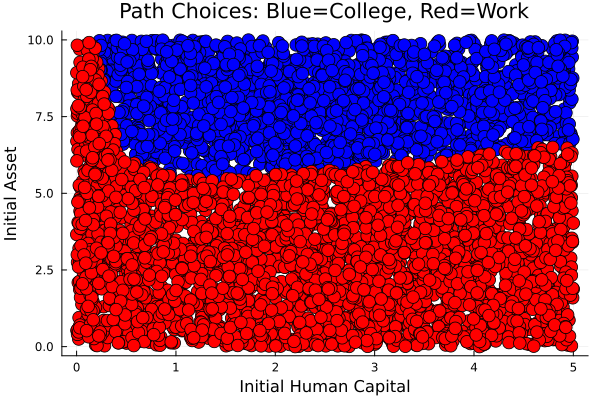

In [33]:
using Plots

# Data
asset = model_baseline.sim_a_init
hc    = model_baseline.sim_k_init
choices = path_choice_baseline  # Vector of :college or :work

# Thresholds (set as needed)
asset_thresh = 6.0
hc_thresh = 1.5

# Color assignment: blue for college, red for work
color_vec = [c == :college ? :blue : :red for c in choices]

# Plot
scatter(
    hc, asset, 
    group=choices,  # not necessary but lets you label if desired
    markercolor=color_vec,
    markersize=7,
    xlabel="Initial Human Capital",
    ylabel="Initial Asset",
    title="Path Choices: Blue=College, Red=Work",
    legend=false,
)

# Threshold lines
#hline!([asset_thresh], linestyle=:dash, color=:black, label="Asset Threshold")
#vline!([hc_thresh], linestyle=:dash, color=:black, label="HC Threshold")



display(current())

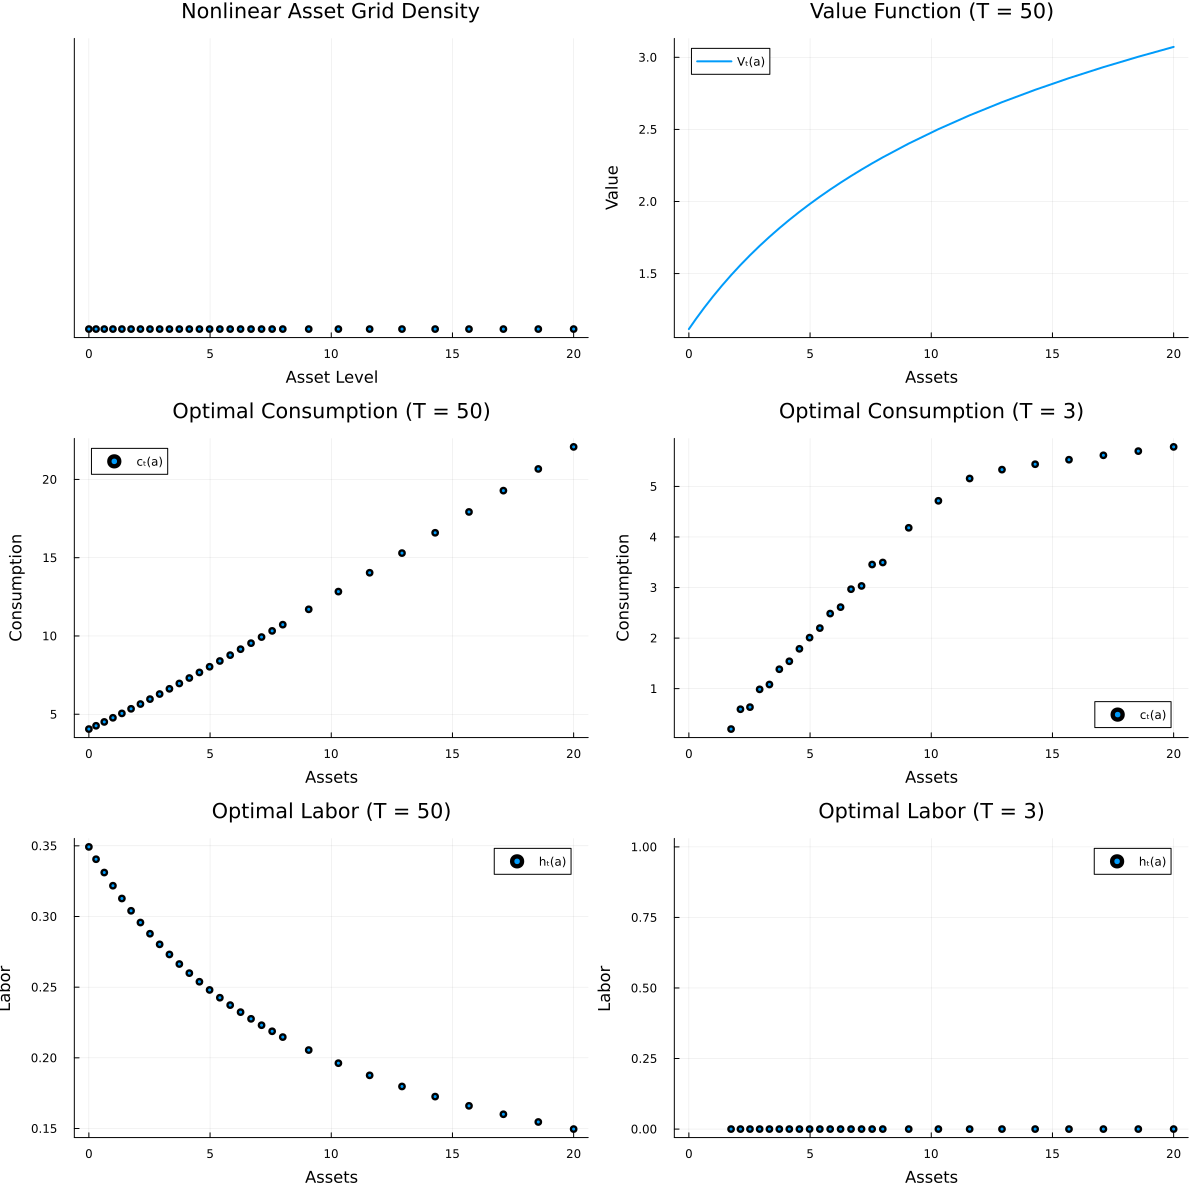

In [34]:

# -----------------------------------------
# Pick “mid‐grid” indices for a, k, t, and p
# -----------------------------------------
k_mid   = ceil(Int, length(model_baseline.k_grid)/2)

p_mid   = ceil(Int, length(model_baseline.p_grid)/2)

T_terminal = model_baseline.T   # terminal period
t_early    = 3           # an earlier period

# 1. Plot the nonlinear asset grid
p1 = scatter(model_baseline.a_grid, zeros(length(model_baseline.a_grid)),
    xlabel = "Asset Level",
    yticks = [],
    title = "Nonlinear Asset Grid Density",
    markersize = 3,
    legend = false)

# 2. Plot optimal consumption policy at terminal period (T = model.T)
# Here we fix the labor dimension at k_mid.
p2 = scatter(model_baseline.a_grid, model_baseline.sol_c_college[T_terminal, :, k_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Consumption",
    title = "Optimal Consumption (T = $(T_terminal))",
    label = "cₜ(a)",
    markersize = 3)

# 3. Plot value function at terminal period (T = model.T)
# Note: use 'sol_v' (not sol_V) as per your definition.
p3 = plot(model_baseline.a_grid, model_baseline.sol_v_college[T_terminal, :, k_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Value",
    title = "Value Function (T = $(T_terminal))",
    label = "Vₜ(a)",
    linewidth = 2)

# 4. Plot optimal consumption policy at an earlier period (e.g., T = 10)
p4 = scatter(model_baseline.a_grid, model_baseline.sol_c_college[t_early, :, k_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Consumption",
    title = "Optimal Consumption (T = $(t_early))",
    label = "cₜ(a)",
    markersize = 3)

p5 = scatter(model_baseline.a_grid, model_baseline.sol_h_college[t_early, :, k_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Labor",
    title = "Optimal Labor (T = $(t_early))",
    label = "hₜ(a)",
    markersize = 3)

p6 = scatter(model_baseline.a_grid, model_baseline.sol_h_college[T_terminal, :, k_mid, p_mid],
    xlabel = "Assets",
    ylabel = "Labor",
    title = "Optimal Labor (T = $(T_terminal))",
    label = "hₜ(a)",
    markersize = 3)

# Combine all plots into a 2×2 grid layout for comparison
plot(p1, p3, p2, p4, p6, p5, layout = (3, 2), size = (1200, 1200))

In [35]:

# -----------------------------
# Extraction function to compute average time series by group
# -----------------------------
function extract_simulation_by_path(model, path_choice)
    T = model.T
    # Find indices of agents by their choice
    college_idx = findall(x -> x == :college, path_choice)
    work_idx    = findall(x -> x == :work, path_choice)
    
    # Compute the average for each time period over the agents in each group
    avg_c_college = [mean(model.sim_c[college_idx, t]) for t in 1:T]
    avg_c_work    = [mean(model.sim_c[work_idx, t]) for t in 1:T]
    
    avg_a_college = [mean(model.sim_a[college_idx, t]) for t in 1:T]
    avg_a_work    = [mean(model.sim_a[work_idx, t]) for t in 1:T]
    
    avg_h_college = [mean(model.sim_h[college_idx, t]) for t in 1:T]
    avg_h_work    = [mean(model.sim_h[work_idx, t]) for t in 1:T]
    
    avg_k_college = [mean(model.sim_k[college_idx, t]) for t in 1:T]
    avg_k_work    = [mean(model.sim_k[work_idx, t]) for t in 1:T]
    
    avg_income_college = [mean(model.sim_income[college_idx, t]) for t in 1:T]
    avg_income_work    = [mean(model.sim_income[work_idx, t]) for t in 1:T]
    
    avg_wage_college = [mean(model.sim_wage[college_idx, t]) for t in 1:T]
    avg_wage_work    = [mean(model.sim_wage[work_idx, t]) for t in 1:T]
    
    return (
      c      = (college = avg_c_college,   work = avg_c_work),
      a      = (college = avg_a_college,   work = avg_a_work),
      h      = (college = avg_h_college,   work = avg_h_work),
      k      = (college = avg_k_college,   work = avg_k_work),
      income = (college = avg_income_college, work = avg_income_work),
      wage   = (college = avg_wage_college,   work = avg_wage_work)
    )
end

extract_simulation_by_path (generic function with 1 method)

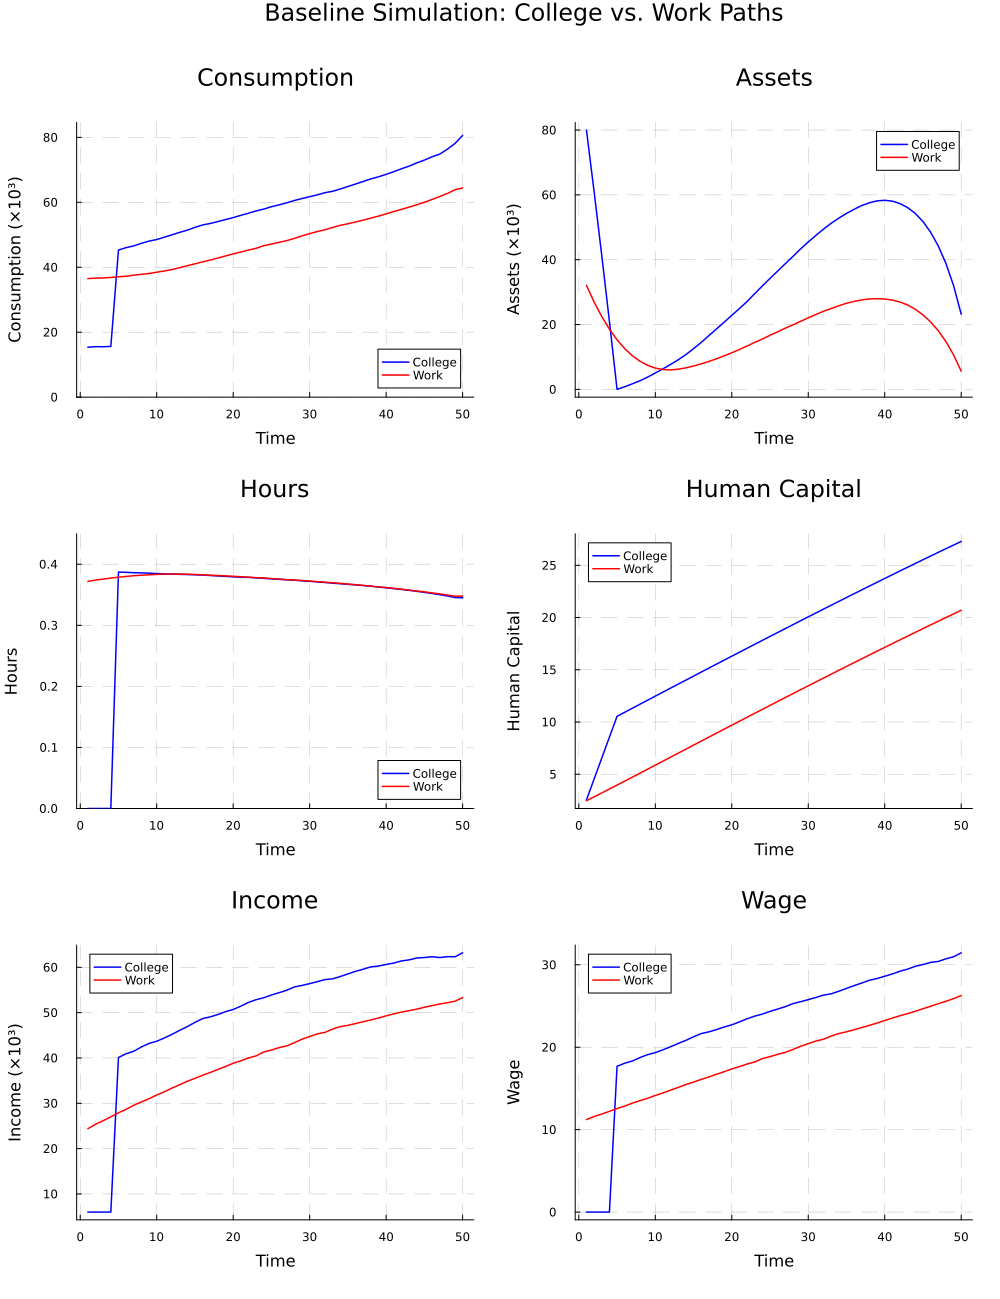

In [36]:

baseline_sim = extract_simulation_by_path(model_baseline, path_choice_baseline)


function plot_simulation_results(model, path_choice, common_title="Counterfactual\n(r increased from X% to Y%)"; baseline_sim=nothing)
    # Extract simulation results for the current model
    sim_results = extract_simulation_by_path(model, path_choice)
    t = 1:model.T  # time vector

    # Colors & line widths
    college_color = :blue
    work_color    = :red
    main_lw       = 1.5
    base_lw       = 1.0

    # Helper for subtle dashed grid lines
    function style_grid!(p)
        plot!(p, grid = :on, gridstyle = :dash, gridcolor = :gray, gridalpha = 0.5)
    end

    # Formatter to divide y-values by 1000 (e.g., 60000 → "60")
    thousand_formatter = (val -> @sprintf("%.0f", val * 10))

    ## ------------------- PLOT 1: Consumption ------------------- ##
    # Plot main lines in solid, baseline in dashed
    ymax_c = maximum(vcat(sim_results.c.college, sim_results.c.work)) * 1.05  # 10% buffer
    p1 = plot(t, sim_results.c.college,
        label = "College", lw = main_lw, color = college_color,
        xlabel = "Time", ylabel = "Consumption (×10³)", ylims = (0, ymax_c),
        title  = "Consumption", legend = :bottomright,
    )
    plot!(p1, t, sim_results.c.work,
        label = "Work", lw = main_lw, color = work_color)

    if baseline_sim !== nothing
        plot!(p1, t, baseline_sim.c.college,
            label = "College (Base)", lw = base_lw, color = college_color,
            linestyle = :dash)
        plot!(p1, t, baseline_sim.c.work,
            label = "Work (Base)", lw = base_lw, color = work_color,
            linestyle = :dash)
    end
    # Apply thousands formatter
    plot!(p1, yformatter = thousand_formatter)
    style_grid!(p1)

    ## ------------------- PLOT 2: Assets ------------------- ##
    p2 = plot(t, sim_results.a.college,
        label = "College", lw = main_lw, color = college_color,
        xlabel = "Time", ylabel = "Assets (×10³)",
        title = "Assets"
    )
    plot!(p2, t, sim_results.a.work,
        label = "Work", lw = main_lw, color = work_color)

    if baseline_sim !== nothing
        plot!(p2, t, baseline_sim.a.college,
            label = "College (Base)", lw = base_lw, color = college_color,
            linestyle = :dash)
        plot!(p2, t, baseline_sim.a.work,
            label = "Work (Base)", lw = base_lw, color = work_color,
            linestyle = :dash)
    end
    # Thousands
    plot!(p2, yformatter = thousand_formatter)
    style_grid!(p2)

    ## ------------------- PLOT 3: Hours ------------------- ##
    # Hours are presumably small, so we don't scale
    p3 = plot(t, sim_results.h.college,
        label = "College", lw = main_lw, color = college_color,
        xlabel = "Time", ylabel = "Hours", ylim = (0, 0.45),
        title = "Hours"
    )
    plot!(p3, t, sim_results.h.work,
        label = "Work", lw = main_lw, color = work_color)

    if baseline_sim !== nothing
        plot!(p3, t, baseline_sim.h.college,
            label = "College (Base)", lw = base_lw, color = college_color,
            linestyle = :dash)
        plot!(p3, t, baseline_sim.h.work,
            label = "Work (Base)", lw = base_lw, color = work_color,
            linestyle = :dash)
    end
    # No thousands scaling
    style_grid!(p3)

    ## ------------------- PLOT 4: Human Capital ------------------- ##
    p4 = plot(t, sim_results.k.college,
        label = "College", lw = main_lw, color = college_color,
        xlabel = "Time", ylabel = "Human Capital", #ylims = (0, 55),
        title = "Human Capital"
    )
    plot!(p4, t, sim_results.k.work,
        label = "Work", lw = main_lw, color = work_color)

    if baseline_sim !== nothing
        plot!(p4, t, baseline_sim.k.college,
            label = "College (Base)", lw = base_lw, color = college_color,
            linestyle = :dash)
        plot!(p4, t, baseline_sim.k.work,
            label = "Work (Base)", lw = base_lw, color = work_color,
            linestyle = :dash)
    end
    # Usually doesn't need thousands scaling, but you can add if your scale is large
    style_grid!(p4)

    ## ------------------- PLOT 5: Income ------------------- ##
    p5 = plot(t, sim_results.income.college,
        label = "College", lw = main_lw, color = college_color,
        xlabel = "Time", ylabel = "Income (×10³)",
        title = "Income"
    )
    plot!(p5, t, sim_results.income.work,
        label = "Work", lw = main_lw, color = work_color)

    if baseline_sim !== nothing
        plot!(p5, t, baseline_sim.income.college,
            label = "College (Base)", lw = base_lw, color = college_color,
            linestyle = :dash)
        plot!(p5, t, baseline_sim.income.work,
            label = "Work (Base)", lw = base_lw, color = work_color,
            linestyle = :dash)
    end
    # Use thousands
    plot!(p5, yformatter = thousand_formatter)
    style_grid!(p5)

    ## ------------------- PLOT 6: Wage ------------------- ##
    p6 = plot(t, sim_results.wage.college,
        label = "College", lw = main_lw, color = college_color,
        xlabel = "Time", ylabel = "Wage",
        title = "Wage"
    )
    plot!(p6, t, sim_results.wage.work,
        label = "Work", lw = main_lw, color = work_color)

    if baseline_sim !== nothing
        plot!(p6, t, baseline_sim.wage.college,
            label = "College (Base)", lw = base_lw, color = college_color,
            linestyle = :dash)
        plot!(p6, t, baseline_sim.wage.work,
            label = "Work (Base)", lw = base_lw, color = work_color,
            linestyle = :dash)
    end
    # Thousands
    plot!(p6)
    style_grid!(p6)

    # Combine the six subplots into a 2x3 layout
    combined_plot = plot(
        p1, p2, p3, p4, p5, p6,
        layout     = (3, 2),
        size       = (1000, 1300),
        plot_title = common_title,
        titlefont  = 16,
        margin     = 5mm
    )

    return combined_plot
end

p_baseline = plot_simulation_results(model_baseline, path_choice_baseline,
                                     "Baseline Simulation: College vs. Work Paths")